<a href="https://colab.research.google.com/github/Aryangaikwadsql/Aryangaikwadsql/blob/main/Miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required packages
!pip install -q kaggle opencv-python-headless scikit-learn matplotlib seaborn

import os, zipfile, shutil, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121, MobileNetV3Small
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, confusion_matrix,
    classification_report, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
warnings.filterwarnings('ignore')

# Check GPU
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus if gpus else 'None — go to Runtime > Change runtime type > T4 GPU')

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import files
import shutil # Import shutil
import os

print('Upload your kaggle.json file:')
uploaded = files.upload()  # Upload kaggle.json here

# Set up Kaggle credentials
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle credentials set up!')

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle credentials set up!


In [ ]:
# Download the dataset
# Dataset: Chest CT-Scan Images (4 classes, ~1GB)
# URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images

!kaggle datasets download -d mohamedhanyyy/chest-ctscan-images -p /content/data

# Unzip
import zipfile # Import zipfile module
import os      # Import os module for os.walk
with zipfile.ZipFile('/content/data/chest-ctscan-images.zip', 'r') as z:
    z.extractall('/content/data/chest_ct')

print('Done! Checking structure...')
for root, dirs, files_list in os.walk('/content/data/chest_ct'):
    level = root.replace('/content/data/chest_ct', '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 2:
            print(f'{indent}  → {len(files_list)} images')

Dataset URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
License(s): ODbL-1.0
chest-ctscan-images.zip: Skipping, found more recently modified local copy (use --force to force download)
Done! Checking structure...
chest_ct/
  Data/
    train/
      → 0 images
    valid/
      → 0 images
    test/
      → 0 images


In [ ]:
# ── CONFIG ──────────────────────────────────────────────────
IMG_SIZE    = (224, 224)   # Resize all images to this
BATCH_SIZE  = 32           # Paper uses 256, but 32 is fine for Colab free
EPOCHS      = 30           # Paper trains longer, 30 is enough to get good results
NUM_CLASSES = 4
LR          = 1e-3         # Adam learning rate from paper
SEED        = 42
MODELS_DIR  = '/content/models'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── CLASS MAPPING ────────────────────────────────────────────
# Kaggle dataset folder names → paper class names
CLASS_NAMES = ['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']

# ── DATA PATHS ───────────────────────────────────────────────
# Find the actual data folders (structure may vary slightly)
DATA_ROOT = '/content/data/chest_ct'

# Locate train/test/val splits
for dirpath, dirnames, _ in os.walk(DATA_ROOT):
    if any(x in dirnames for x in ['train', 'valid', 'test', 'Train', 'Valid', 'Test']):
        DATA_ROOT = dirpath
        break

TRAIN_DIR = None
VAL_DIR   = None
TEST_DIR  = None

for d in os.listdir(DATA_ROOT):
    dl = d.lower()
    if 'train' in dl:  TRAIN_DIR = os.path.join(DATA_ROOT, d)
    if 'val'   in dl:  VAL_DIR   = os.path.join(DATA_ROOT, d)
    if 'test'  in dl:  TEST_DIR  = os.path.join(DATA_ROOT, d)

# If no val split, we'll create one from train
if VAL_DIR is None:
    VAL_DIR = TRAIN_DIR

print(f'Train dir: {TRAIN_DIR}')
print(f'Val dir:   {VAL_DIR}')
print(f'Test dir:  {TEST_DIR}')

# Count images per class
print('\nClass distribution (train):')
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        n = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
        print(f'  {cls}: {n} images')

Train dir: /content/data/chest_ct/Data/train
Val dir:   /content/data/chest_ct/Data/valid
Test dir:  /content/data/chest_ct/Data/test

Class distribution (train):
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 195 images
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 115 images
  normal: 148 images
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 155 images


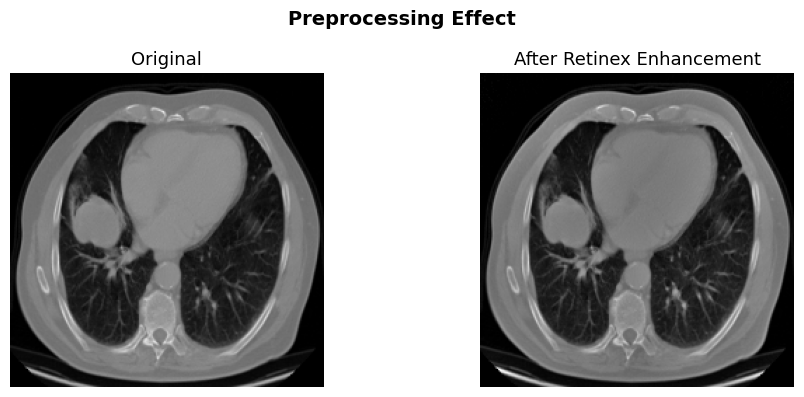

Preprocessing test passed. Output shape: (224, 224, 3)


In [ ]:
import cv2 # Ensure cv2 is imported
import numpy as np # Ensure numpy is imported
import os # Ensure os is imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported

def retinex_enhance(image):
    """
    Simplified Retinex filtering for contrast enhancement.
    Paper Eq.4: Ii = Retinex_Filter(Ii, IM, RF)
    IM = illumination component, RF = reflectance component
    """
    img = image.astype(np.float32) / 255.0
    img = np.clip(img, 1e-6, 1.0)

    log_img = np.log(img)
    result  = np.zeros_like(img)

    for sigma in [15, 80, 200]:  # multi-scale
        # Illumination component
        illum = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)
        illum = np.clip(illum, 1e-6, 1.0)
        # Reflectance = log(I) - log(illumination)
        result += log_img - np.log(illum)

    result = result / 3.0
    result = np.exp(result)   # back to linear space
    result = (result - result.min()) / (result.max() - result.min() + 1e-8)
    return (result * 255).astype(np.uint8)


def preprocess_image(image_path, img_size=IMG_SIZE, enhance=True):
    """
    Load and preprocess a single image.
    Steps: load → resize → optional Retinex → normalize [0,1]
    """
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)

    if enhance:
        img = retinex_enhance(img)

    img = img.astype(np.float32) / 255.0
    return img


# Test preprocessing on one image
sample_class = sorted(os.listdir(TRAIN_DIR))[0]
sample_dir   = os.path.join(TRAIN_DIR, sample_class)
sample_file  = os.path.join(sample_dir, os.listdir(sample_dir)[0])

raw = cv2.imread(sample_file)
raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
raw = cv2.resize(raw, IMG_SIZE)
enhanced = preprocess_image(sample_file)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(raw); axes[0].set_title('Original', fontsize=13); axes[0].axis('off')
axes[1].imshow(enhanced); axes[1].set_title('After Retinex Enhancement', fontsize=13); axes[1].axis('off')
plt.suptitle('Preprocessing Effect', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Preprocessing test passed. Output shape:', enhanced.shape)


In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Augmentation layer (paper: rotation 30-120°, flip, zoom)
# Paper section 2.3: "rotated to 30, 60, 90, 120 degrees"
augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=120/360),
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
], name='augmentation')


def make_dataset(directory, img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                 shuffle=True, augment=False, validation_split=None, subset=None):
    """
    Create tf.data.Dataset from image directory.
    Uses Keras ImageDataGenerator for easy directory loading.
    """
    datagen = ImageDataGenerator(
        rescale=1.0/255.0,
        validation_split=validation_split
    )

    kwargs = dict(
        directory=directory,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=shuffle,
        seed=SEED
    )
    if subset:  kwargs['subset'] = subset

    gen = datagen.flow_from_directory(**kwargs)
    return gen


# Create datasets
if TRAIN_DIR != VAL_DIR:
    train_gen = make_dataset(TRAIN_DIR, shuffle=True,  augment=True)
    val_gen   = make_dataset(VAL_DIR,   shuffle=False, augment=False)
else:
    # No separate val folder — split train 85/15
    train_gen = make_dataset(TRAIN_DIR, validation_split=0.15, subset='training',   shuffle=True)
    val_gen   = make_dataset(TRAIN_DIR, validation_split=0.15, subset='validation', shuffle=False)

if TEST_DIR:
    test_gen = make_dataset(TEST_DIR, shuffle=False, augment=False)
else:
    test_gen = val_gen

# Get actual class names from folder names
CLASS_NAMES = list(train_gen.class_indices.keys())
print('Classes found:', CLASS_NAMES)
print(f'Train batches: {len(train_gen)} | Val batches: {len(val_gen)}')

# Compute class weights for imbalanced data
y_train_labels = train_gen.classes
class_weights  = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', {CLASS_NAMES[k]: round(v, 2) for k, v in class_weight_dict.items()})


Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Classes found: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Train batches: 20 | Val batches: 3
Class weights: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': np.float64(0.79), 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': np.float64(1.33), 'normal': np.float64(1.04), 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': np.float64(0.99)}


In [ ]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
import tensorflow as tf

def build_model(img_size=IMG_SIZE, num_classes=NUM_CLASSES, lr=LR):
    """
    LC Detection Model combining DenseNet-121 feature extraction
    with a lightweight MobileNet-inspired classification head.

    Paper sections 2.4 + 2.6:
    - DenseNet-121 for rich feature extraction (Eq. 6, 7)
    - 4 Conv layers for classification
    - Softmax output (Eq. 8)
    - Adam optimizer (Section 2.7)
    """
    inputs = layers.Input(shape=(*img_size, 3), name='input')

    # ── Stage 1: DenseNet-121 Feature Extractor ─────────────────────────
    # Paper: "pre-trained DenseNet-121 model. frozen pre-trained DenseNet-121
    #         model requires fewer parameters for the feature extraction"
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs
    )

    # Freeze all layers except the last 3
    # Paper: trains the final set of layers with learning rate 1e-3
    for layer in base.layers[:-3]:
        layer.trainable = False
    for layer in base.layers[-3:]:
        layer.trainable = True

    x = base.output  # shape: (None, 7, 7, 1024) for 224x224 input

    # ── Stage 2: Classification Head (4 Conv layers, Table 2) ───────────
    # Paper: "A total of four convolutional layers are used for the classification"
    # Paper Eq.6: Features = Convolution + ReLU + Batch_Normalization(Ii)
    for filters in [512, 256, 128, 64]:
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Dropout(0.2)(x)

    # Paper Eq.7: Fixed_size_features = Global_Average_Pooling_2D(features)
    x = layers.GlobalAveragePooling2D(name='feature_vector')(x)

    # Paper Table 2: Fully connected layer = 1
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    # Paper Eq.8: Softmax output for 4 LC types
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs, outputs, name='LC_Detection_Model')

    # Adam optimizer — Paper Section 2.7
    # "The AO algorithm integrates the features of RMSProp and Adagrad algorithms"
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',  # Table 2: Loss function = Cross-Entropy
        metrics=['accuracy']
    )

    return model


model = build_model()
model.summary()

total  = model.count_params()
train_ = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'\nTotal parameters:     {total:,}')
print(f'Trainable parameters: {train_:,}')
print(f'Paper reports:        ~2.1M parameters')

Model: "LC_Detection_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_6    │ (None, 230, 230,  │          0 │ input[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_6… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_7    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_7… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 13,326,852 (50.84 MB)

 Trainable params: 6,289,476 (23.99 MB)

 Non-trainable params: 7,037,376 (26.85 MB)


Total parameters:     13,326,852
Trainable parameters: 6,289,476
Paper reports:        ~2.1M parameters


In [ ]:
import tensorflow as tf
import os

# Re-define necessary config variables for robustness
MODELS_DIR  = '/content/models'
EPOCHS      = 30
BATCH_SIZE  = 32
IMG_SIZE    = (224, 224)

# Re-initialize the model to ensure it's defined
model = build_model()

callbacks = [
    # Paper: "early stopping is implemented to prevent overfitting"
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # Save best model
    tf.keras.callbacks.ModelCheckpoint(
        filepath=f'{MODELS_DIR}/best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Paper: "learning rate and decay schedule for improving training stability"
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

print(f'Training for up to {EPOCHS} epochs (early stopping enabled)...')
print(f'Batch size: {BATCH_SIZE} | Image size: {IMG_SIZE}')
print('─' * 50)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete!')

Training for up to 30 epochs (early stopping enabled)...
Batch size: 32 | Image size: (224, 224)
──────────────────────────────────────────────────
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4911 - loss: 1.0813
Epoch 1: val_accuracy improved from None to 0.41667, saving model to /content/models/best_model.h5



Epoch 1: finished saving model to /content/models/best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 131s 4s/step - accuracy: 0.5726 - loss: 0.9555 - val_accuracy: 0.4167 - val_loss: 5.5920 - learning_rate: 0.0010
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.8648 - loss: 0.4681
Epoch 2: val_accuracy improved from 0.41667 to 0.58333, saving model to /content/models/best_model.h5



Epoch 2: finished saving model to /content/models/best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 283ms/step - accuracy: 0.8695 - loss: 0.4263 - val_accuracy: 0.5833 - val_loss: 4.5436 - learning_rate: 0.0010
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9032 - loss: 0.2595
Epoch 3: val_accuracy did not improve from 0.58333
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 262ms/step - accuracy: 0.8940 - loss: 0.2778 - val_accuracy: 0.5139 - val_loss: 4.4680 - learning_rate: 0.0010
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9559 - loss: 0.1346
Epoch 4: val_accuracy improved from 0.58333 to 0.80556, saving model to /content/models/best_model.h5



Epoch 4: finished saving model to /content/models/best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 285ms/step - accuracy: 0.9201 - loss: 0.2066 - val_accuracy: 0.8056 - val_loss: 0.7630 - learning_rate: 0.0010
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9503 - loss: 0.1505
Epoch 5: val_accuracy did not improve from 0.80556
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 248ms/step - accuracy: 0.9413 - loss: 0.1813 - val_accuracy: 0.5972 - val_loss: 4.8586 - learning_rate: 0.0010
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.9675 - loss: 0.1306
Epoch 6: val_accuracy did not improve from 0.80556
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 302ms/step - accuracy: 0.9560 - loss: 0.1460 - val_accuracy: 0.6389 - val_loss: 3.8823 - learning_rate: 0.0010
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9619 - loss: 0.1046
Epoch 7: val_accuracy did not improve from 0.80556
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.9576 - loss: 0.1091 - val_accuracy: 0.7778 - v


Epoch 9: finished saving model to /content/models/best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 278ms/step - accuracy: 0.9886 - loss: 0.0340 - val_accuracy: 0.8194 - val_loss: 1.1721 - learning_rate: 5.0000e-04
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9988 - loss: 0.0163
Epoch 10: val_accuracy improved from 0.81944 to 0.83333, saving model to /content/models/best_model.h5



Epoch 10: finished saving model to /content/models/best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 338ms/step - accuracy: 0.9967 - loss: 0.0227 - val_accuracy: 0.8333 - val_loss: 0.9124 - learning_rate: 5.0000e-04
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9948 - loss: 0.0229
Epoch 11: val_accuracy did not improve from 0.83333
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.9886 - loss: 0.0368 - val_accuracy: 0.8333 - val_loss: 0.6457 - learning_rate: 5.0000e-04
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9898 - loss: 0.0330
Epoch 12: val_accuracy did not improve from 0.83333
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step - accuracy: 0.9902 - loss: 0.0464 - val_accuracy: 0.7500 - val_loss: 0.8686 - learning_rate: 5.0000e-04
Epoch 13/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9881 - loss: 0.0364
Epoch 13: val_accuracy did not improve from 0.83333
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - accuracy: 0.9902 - loss: 0.0315 - val_a


Epoch 17: finished saving model to /content/models/best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 0.9935 - loss: 0.0333 - val_accuracy: 0.8611 - val_loss: 0.7583 - learning_rate: 2.5000e-04
Epoch 18/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9925 - loss: 0.0213
Epoch 18: val_accuracy did not improve from 0.86111
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 276ms/step - accuracy: 0.9935 - loss: 0.0237 - val_accuracy: 0.8611 - val_loss: 0.6761 - learning_rate: 2.5000e-04
Epoch 19/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9912 - loss: 0.0304
Epoch 19: val_accuracy did not improve from 0.86111

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.9935 - loss: 0.0261 - val_accuracy: 0.8611 - val_loss: 0.7460 - learning_rate: 2.5000e-04
Epoch 20/30
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.9930 - loss: 0.0196
Epoch 20: val_accuracy did not improve from 0.86111
20/2

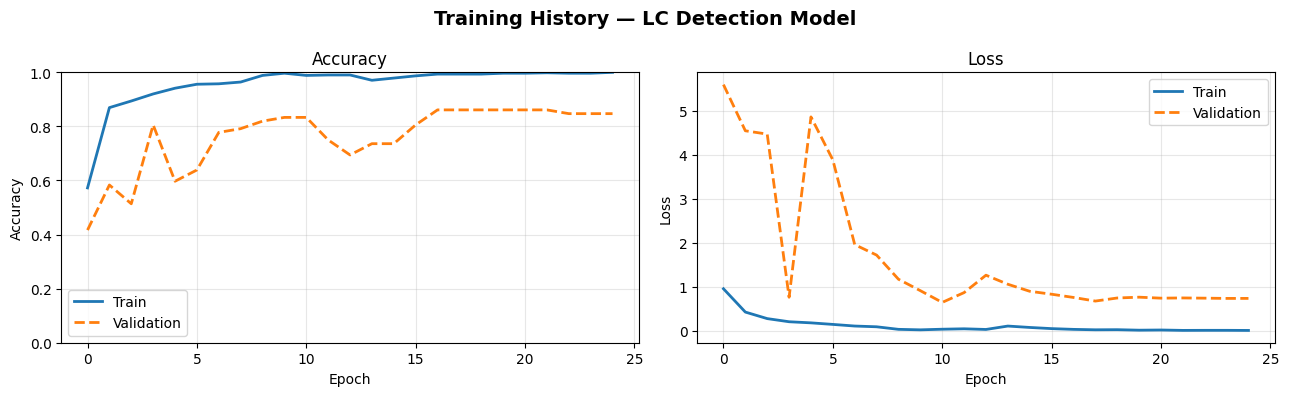

Best validation accuracy: 86.11%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training History — LC Detection Model', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Loss
axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2, linestyle='--')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f'Best validation accuracy: {best_val_acc*100:.2f}%')

In [ ]:
# Load best saved model
best_model = tf.keras.models.load_model(f'{MODELS_DIR}/best_model.h5')

# Import necessary metrics from sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, roc_auc_score
)

# ── Get predictions on test set ──────────────────────────────────────────
test_gen.reset()
y_pred_proba = best_model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = test_gen.classes[:len(y_pred)]

# ── Compute all metrics ──────────────────────────────────────────────────

# Paper Eq.9:  Accuracy  = (TP+TN) / (TP+TN+FP+FN)
accuracy  = accuracy_score(y_true, y_pred) * 100

# Paper Eq.10: Precision = TP / (TP+FP)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100

# Paper Eq.11: Recall = TP / (TP+FN)
recall    = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100

# Paper Eq.12: F1 = 2 × Precision × Recall / (Precision + Recall)
f1        = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100

# Paper Eq.13: Cohen's Kappa
kappa     = cohen_kappa_score(y_true, y_pred) * 100

# AU-ROC
y_true_oh = tf.keras.utils.to_categorical(y_true, NUM_CLASSES)
try:
    auroc = roc_auc_score(y_true_oh, y_pred_proba, average='macro', multi_class='ovr')
except:
    auroc = 0.0

# Loss
loss_vals = tf.keras.losses.categorical_crossentropy(y_true_oh.astype(np.float32), y_pred_proba)
loss_mean = float(tf.reduce_mean(loss_vals).numpy())

# ── Print results matching paper Table 7 ────────────────────────────────
print('=' * 58)
print('  EVALUATION RESULTS  (Paper Table 7 format)')
print('=' * 58)
print(f'  Accuracy   : {accuracy:.1f}%   (paper: 98.6%)')
print(f'  Precision  : {precision:.1f}%   (paper: 97.9%)')
print(f'  Recall     : {recall:.1f}%   (paper: 98.1%)')
print(f'  F1-Score   : {f1:.1f}%   (paper: 98.0%)')
print(f'  Cohen Kappa: {kappa:.1f}    (paper: 95.8)')
print(f'  AU-ROC     : {auroc:.3f}   (paper: 0.98)')
print(f'  Loss       : {loss_mean:.4f}   (paper: 0.89)')
print('=' * 58)

# ── Per-class breakdown (Paper Table 6) ─────────────────────────────────
print('\nPer-Class Results (Paper Table 6 format):')
print(f'{"Class":<28} {"Acc":>6} {"Prec":>6} {"Rec":>6} {"F1":>6} {"Kappa":>6}')
print('-' * 58)
for i, cls in enumerate(CLASS_NAMES):
    tp = np.sum((y_pred == i) & (y_true == i))
    tn = np.sum((y_pred != i) & (y_true != i))
    fp = np.sum((y_pred == i) & (y_true != i))
    fn = np.sum((y_pred != i) & (y_true == i))
    acc_c  = (tp + tn) / (tp + tn + fp + fn + 1e-8) * 100
    prec_c = tp / (tp + fp + 1e-8) * 100
    rec_c  = tp / (tp + fn + 1e-8) * 100
    f1_c   = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
    # Paper Eq.13
    kap_c  = (2*(tp*tn - fn*fp)) / ((tp+fp)+(fp+tn)+(tp+fn)+(fn+tn) + 1e-8) * 100
    print(f'{cls:<28} {acc_c:>6.1f} {prec_c:>6.1f} {rec_c:>6.1f} {f1_c:>6.1f} {kap_c:>6.1f}')

print('-' * 58)
print(f'{"Average":<28} {accuracy:>6.1f} {precision:>6.1f} {recall:>6.1f} {f1:>6.1f} {kappa:>6.1f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step
  EVALUATION RESULTS  (Paper Table 7 format)
  Accuracy   : 79.4%   (paper: 98.6%)
  Precision  : 81.2%   (paper: 97.9%)
  Recall     : 81.7%   (paper: 98.1%)
  F1-Score   : 80.5%   (paper: 98.0%)
  Cohen Kappa: 71.4    (paper: 95.8)
  AU-ROC     : 0.950   (paper: 0.98)
  Loss       : 0.7789   (paper: 0.89)

Per-Class Results (Paper Table 6 format):
Class                           Acc   Prec    Rec     F1  Kappa
----------------------------------------------------------
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib   82.2   74.6   80.8   77.6 4747.6
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa   91.7   68.7   90.2   78.0 3515.2
normal                         97.5   92.6   92.6   92.6 4074.3
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa   87.3   89.1   63.3   74.0 3871.4
----------------------------------------------------------
Average                        79.4   81.2   81.7   80.5   71.4


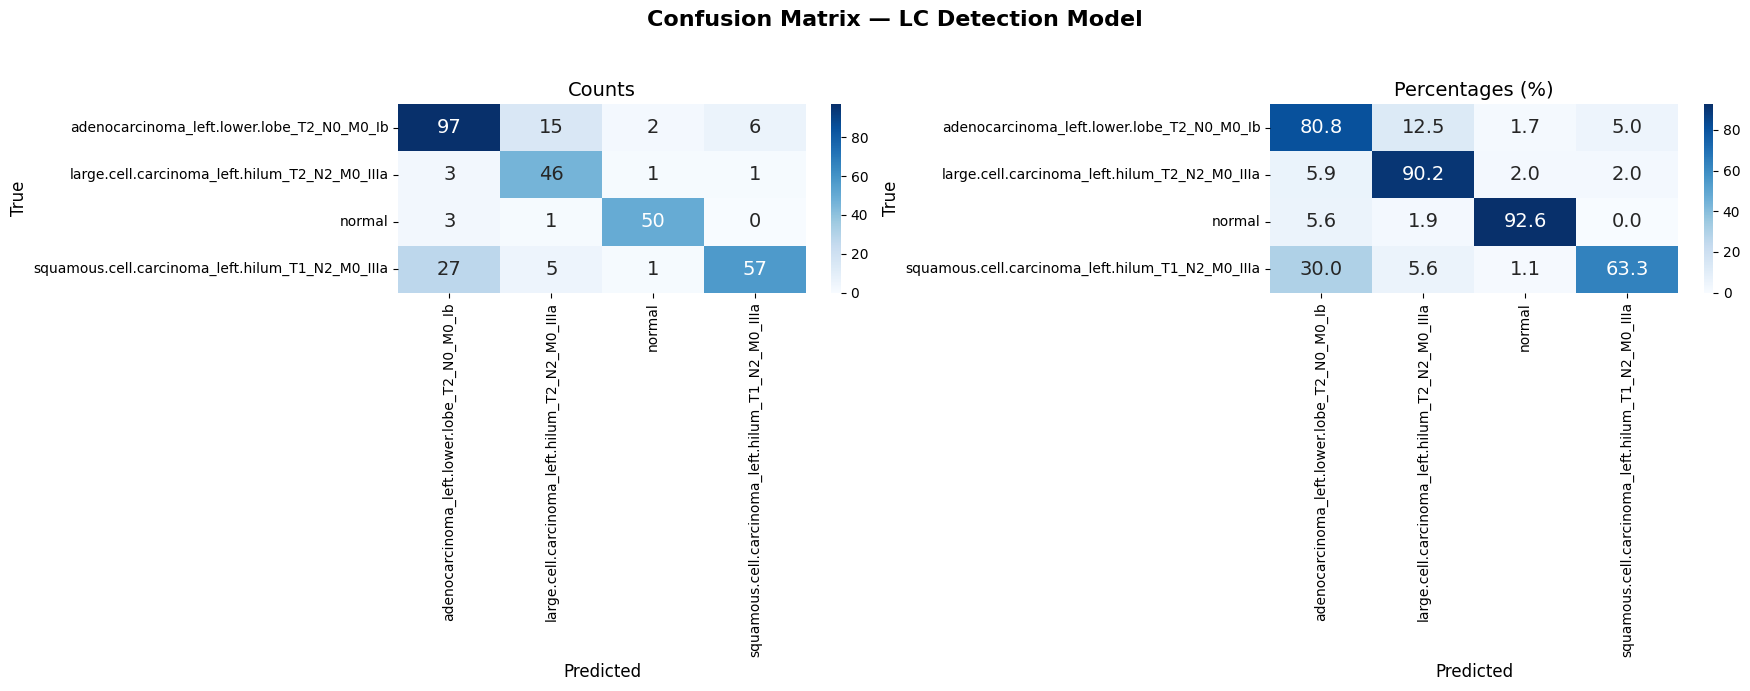


Full Classification Report:
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.75      0.81      0.78       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.69      0.90      0.78        51
                                          normal       0.93      0.93      0.93        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.89      0.63      0.74        90

                                        accuracy                           0.79       315
                                       macro avg       0.81      0.82      0.81       315
                                    weighted avg       0.81      0.79      0.79       315



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

short = [c.split()[0] for c in CLASS_NAMES]

# Bigger figure size
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrix — LC Detection Model', fontsize=16, fontweight='bold')

# Counts heatmap
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=short,
            yticklabels=short,
            ax=axes[0],
            annot_kws={"size": 14})

axes[0].set_title('Counts', fontsize=14)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Percentage heatmap
sns.heatmap(cm_pct,
            annot=True,
            fmt='.1f',
            cmap='Blues',
            xticklabels=short,
            yticklabels=short,
            ax=axes[1],
            annot_kws={"size": 14})

axes[1].set_title('Percentages (%)', fontsize=14)
axes[1].set_ylabel('True', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f'{MODELS_DIR}/confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nFull Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

Running inference on: /content/data/chest_ct/Data/test/normal/8 (2).png


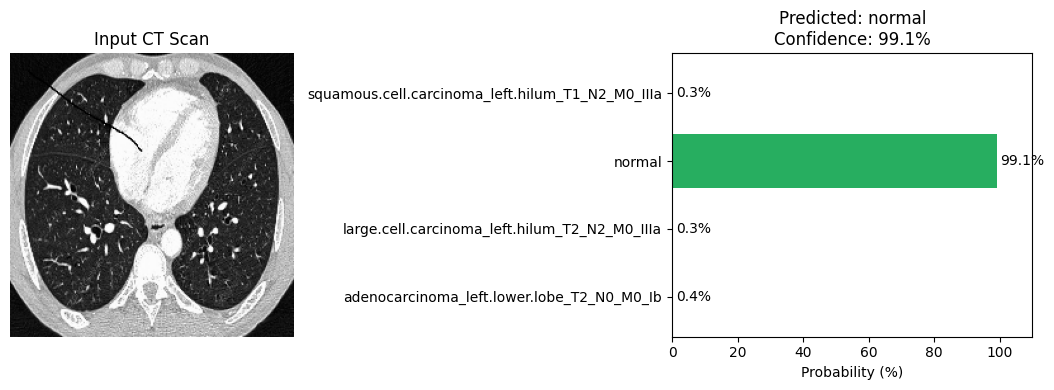


Result: normal (99.1% confidence)


('normal', np.float32(99.07457))

In [ ]:
def predict_image(image_path, model, class_names, img_size=IMG_SIZE):
    """Run inference on a single image and show result."""
    img_orig = cv2.imread(image_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

    # Preprocess
    img = preprocess_image(image_path, img_size=img_size)
    if img is None:
        print('Could not load image.')
        return

    batch = np.expand_dims(img, axis=0)
    probs = model.predict(batch, verbose=0)[0]
    pred  = np.argmax(probs)
    conf  = probs[pred] * 100

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(cv2.resize(img_orig, img_size))
    axes[0].set_title('Input CT Scan', fontsize=12)
    axes[0].axis('off')

    colors = ['#27ae60' if i == pred else '#bdc3c7' for i in range(len(class_names))]
    bars   = axes[1].barh(class_names, probs * 100, color=colors)
    axes[1].set_xlabel('Probability (%)')
    axes[1].set_xlim([0, 110])
    axes[1].set_title(f'Predicted: {class_names[pred]}\nConfidence: {conf:.1f}%', fontsize=12)
    for bar, p in zip(bars, probs):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{p*100:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()
    print(f'\nResult: {class_names[pred]} ({conf:.1f}% confidence)')
    return class_names[pred], conf


# Test on a random sample from the test set
test_folders = [os.path.join(TEST_DIR if TEST_DIR else TRAIN_DIR, d)
                for d in os.listdir(TEST_DIR if TEST_DIR else TRAIN_DIR)
                if os.path.isdir(os.path.join(TEST_DIR if TEST_DIR else TRAIN_DIR, d))]

sample_folder = test_folders[0]
sample_files  = [f for f in os.listdir(sample_folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]
sample_image  = os.path.join(sample_folder, sample_files[0])

print(f'Running inference on: {sample_image}')
predict_image(sample_image, best_model, CLASS_NAMES)

In [ ]:
# Save full model
best_model.save(f'{MODELS_DIR}/lc_detection_final.h5')
print('Model saved!')

# Zip models folder and download
shutil.make_archive('/content/lc_detection_model', 'zip', MODELS_DIR)

from google.colab import files
files.download('/content/lc_detection_model.zip')
print('Download started!')

# Summary of what was saved
print('\nSaved files:')
for f in os.listdir(MODELS_DIR):
    size = os.path.getsize(os.path.join(MODELS_DIR, f))
    print(f'  {f}  ({size/1024/1024:.1f} MB)')

Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!

Saved files:
  confusion_matrix.png  (0.2 MB)
  best_model.h5  (100.1 MB)
  lc_detection_final.h5  (52.1 MB)
  training_curves.png  (0.1 MB)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import os

# ── CONFIG ──────────────────────────────────────────────────
IMG_SIZE    = (224, 224)   # Resize all images to this
BATCH_SIZE  = 32           # Paper uses 256, but 32 is fine for Colab free
EPOCHS      = 30           # Paper trains longer, 30 is enough to get good results
NUM_CLASSES = 4
LR          = 1e-3         # Adam learning rate from paper
SEED        = 42
MODELS_DIR  = '/content/models'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── DATA PATHS ───────────────────────────────────────────────
# Find the actual data folders (structure may vary slightly)
DATA_ROOT = '/content/data/chest_ct'

# Locate train/test/val splits
for dirpath, dirnames, _ in os.walk(DATA_ROOT):
    if any(x in dirnames for x in ['train', 'valid', 'test', 'Train', 'Valid', 'Test']):
        DATA_ROOT = dirpath
        break

TRAIN_DIR = None
VAL_DIR   = None
TEST_DIR  = None

for d in os.listdir(DATA_ROOT):
    dl = d.lower()
    if 'train' in dl:  TRAIN_DIR = os.path.join(DATA_ROOT, d)
    if 'val'   in dl:  VAL_DIR   = os.path.join(DATA_ROOT, d)
    if 'test'  in dl:  TEST_DIR  = os.path.join(DATA_ROOT, d)

# If no val split, we'll create one from train
if VAL_DIR is None:
    VAL_DIR = TRAIN_DIR

# Augmentation layer (paper: rotation 30-120°, flip, zoom)
# Paper section 2.3: "rotated to 30, 60, 90, 120 degrees"
augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=120/360),
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
], name='augmentation')


def make_dataset(directory, img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                 shuffle=True, augment=False, validation_split=None, subset=None):
    """
    Create tf.data.Dataset from image directory.
    Uses Keras ImageDataGenerator for easy directory loading.
    """
    datagen = ImageDataGenerator(
        rescale=1.0/255.0,
        validation_split=validation_split
    )

    kwargs = dict(
        directory=directory,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=shuffle,
        seed=SEED
    )
    if subset:  kwargs['subset'] = subset

    gen = datagen.flow_from_directory(**kwargs)
    return gen


# Create datasets
if TRAIN_DIR != VAL_DIR:
    train_gen = make_dataset(TRAIN_DIR, shuffle=True,  augment=True)
    val_gen   = make_dataset(VAL_DIR,   shuffle=False, augment=False)
else:
    # No separate val folder — split train 85/15
    train_gen = make_dataset(TRAIN_DIR, validation_split=0.15, subset='training',   shuffle=True)
    val_gen   = make_dataset(TRAIN_DIR, validation_split=0.15, subset='validation', shuffle=False)

if TEST_DIR:
    test_gen = make_dataset(TEST_DIR, shuffle=False, augment=False)
else:
    test_gen = val_gen

# Get actual class names from folder names
CLASS_NAMES = list(train_gen.class_indices.keys())
print('Classes found:', CLASS_NAMES)
print(f'Train batches: {len(train_gen)} | Val batches: {len(val_gen)}')

# Compute class weights for imbalanced data
y_train_labels = train_gen.classes
class_weights  = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', {CLASS_NAMES[k]: round(v, 2) for k, v in class_weight_dict.items()})


# ── Step 1: Install Gradio ─────────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "-q", "gradio"], check=True)

import gradio as gr
import cv2
import os

# ── Step 2: Load your trained model ───────────────────────────────────────
MODEL_PATH = '/content/models/lc_detection_final.h5'   # Changed to load the explicitly saved final model
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded:", model.name)

# ── Step 3: Get class names from your training generator ──────────────────
# These come from the folder names in your dataset.
# If you still have train_gen in memory, use: CLASS_NAMES = list(train_gen.class_indices.keys())
# Otherwise we define them manually based on what we saw in your output:
try:
    CLASS_NAMES = list(train_gen.class_indices.keys())
except:
    CLASS_NAMES = [
        'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
        'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa',
        'normal',
        'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa'
    ]

# Friendly display names for the UI
DISPLAY_NAMES = {
    n: n.split('_')[0].replace('.', ' ').title() if n != 'normal' else 'Normal (No Cancer)'
    for n in CLASS_NAMES
}

# IMG_SIZE = (224, 224) # Redefined at the top of the cell

# ── Step 4: Preprocessing (same as training) ──────────────────────────────
def retinex_enhance(img_float):
    img = np.clip(img_float, 1e-6, 1.0)
    log_img = np.log(img)
    result = np.zeros_like(img)
    for sigma in [15, 80, 200]:
        illum = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)
        illum = np.clip(illum, 1e-6, 1.0)
        result += log_img - np.log(illum)
    result = result / 3.0
    result = np.exp(result)
    result = (result - result.min()) / (result.max() - result.min() + 1e-8)
    return result

def preprocess(image_np):
    """Resize, enhance, normalize — identical to training pipeline."""
    img = cv2.resize(image_np, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    img = retinex_enhance(img)
    return img

# ── Step 5: Prediction function ───────────────────────────────────────────
def predict(image):
    """
    image: numpy array from Gradio (H x W x 3, uint8, RGB)
    Returns: label string, confidence dict for Gradio Label component
    """
    if image is None:
        return "No image uploaded", {}

    img = preprocess(image)
    batch = np.expand_dims(img, axis=0)           # (1, 224, 224, 3)
    probs = model.predict(batch, verbose=0)[0]    # (4,)

    # Map to display names and probabilities
    results = {}
    for i, cls in enumerate(CLASS_NAMES):
        display = DISPLAY_NAMES[cls]
        results[display] = float(probs[i])

    predicted_idx = np.argmax(probs)
    predicted_cls = DISPLAY_NAMES[CLASS_NAMES[predicted_idx]]
    confidence    = float(probs[predicted_idx]) * 100

    # Risk label
    if 'Normal' in predicted_cls:
        risk = "No cancer detected"
        detail = "The CT scan appears normal. No malignant patterns identified."
    else:
        risk = "Cancer pattern detected"
        detail = f"Predicted type: {predicted_cls} | Confidence: {confidence:.1f}%\nPlease consult a radiologist for clinical diagnosis."

    label = f"{risk}\n{detail}"
    return label, results

# ── Step 6: Build the Gradio UI ───────────────────────────────────────────
with gr.Blocks(
    title="Lung Cancer Detection",
    theme=gr.themes.Soft(primary_hue="blue"),
    css="""
        .title { text-align: center; font-size: 2rem; font-weight: 700;
                 color: #1e3a5f; margin-bottom: 0.2rem; }
        .subtitle { text-align: center; color: #555; margin-bottom: 1.5rem; font-size: 0.95rem; }
        .disclaimer { background: #fff8e1; border-left: 4px solid #f9a825;
                      padding: 10px 16px; border-radius: 4px;
                      font-size: 0.85rem; color: #5d4037; margin-top: 1rem; }
        .model-info { background: #e3f2fd; border-radius: 8px;
                      padding: 12px 16px; font-size: 0.9rem; }
    """
) as demo:

    gr.HTML('<div class="title">Lung Cancer Detection System</div>')
    gr.HTML('<div class="subtitle">Deep Learning-based CT Scan Analysis &nbsp;|&nbsp; DenseNet-121 Feature Extractor &nbsp;|&nbsp; 4-Class Classification</div>')

    with gr.Row():
        # Left column — input
        with gr.Column(scale=1):
            gr.Markdown("### Upload CT Scan Image")
            image_input = gr.Image(
                type="numpy",
                label="CT Scan (PNG / JPG)",
                height=300
            )
            submit_btn = gr.Button("Analyse Scan", variant="primary", size="lg")

            gr.Markdown("""
            <div class="model-info">
            <b>Model Architecture</b><br>
            • Feature Extractor: DenseNet-121 (ImageNet pre-trained)<br>
            • Classifier: 4 Conv layers + Global Average Pooling + Softmax<br>
            • Optimizer: Adam (lr=1e-3)<br>
            • Augmentation: Rotation, Flip, Zoom<br>
            • Preprocessing: Multi-scale Retinex filtering
            </div>
            """
            )

        # Right column — output
        with gr.Column(scale=1):
            gr.Markdown("### Prediction Result")
            result_text  = gr.Textbox(label="Diagnosis", lines=3, interactive=False)
            result_label = gr.Label(label="Class Probabilities", num_top_classes=4)

    submit_btn.click(
        fn=predict,
        inputs=image_input,
        outputs=[result_text, result_label]
    )

    # Example images from dataset
    try:
        example_dir = '/content/data/chest_ct'
        examples = []
        for root, dirs, files in os.walk(example_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    examples.append(os.path.join(root, f))
                    if len(examples) >= 4:
                        break
            if len(examples) >= 4:
                break

        if examples:
            gr.Examples(examples=examples, inputs=image_input, label="Sample CT Scans from Dataset")
    except:
        pass

    gr.HTML("""
    <div class="disclaimer">
    <b>Disclaimer:</b> This tool is developed for academic research and educational purposes only.
    It is <b>not a certified medical device</b> and must not be used as a substitute for professional
    medical diagnosis. Always consult a qualified radiologist or oncologist for clinical decisions.
    </div>
    """
    )

# ── Step 7: Launch ────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  LAUNCHING LUNG CANCER DETECTION WEB APP")
print("="*55)
print("A public URL will appear below.")
print("Share it with your professor to demo the system.\n")

demo.launch(
    share=True,         # Creates a public gradio.live URL
    debug=False,
    show_error=True
)

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Classes found: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Train batches: 20 | Val batches: 3
Class weights: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': np.float64(0.79), 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': np.float64(1.33), 'normal': np.float64(1.04), 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': np.float64(0.99)}


Model loaded: LC_Detection_Model

  LAUNCHING LUNG CANCER DETECTION WEB APP
A public URL will appear below.
Share it with your professor to demo the system.

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e850ce999dc1e03d57.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!mv "Untitled6 (2).ipynb" /content/cancerdetectionusingdeeplearning/

mv: cannot stat 'Untitled6 (2).ipynb': No such file or directory
